In [3]:
import jax
import jax.numpy as jnp
import jax.image
import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np


2025-03-06 13:22:03.101691: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741285323.112045  481744 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741285323.115197  481744 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:

def load_and_preprocess_mnist():
    # Build and prepare the MNIST dataset using tensorflow_datasets.
    ds_builder = tfds.builder("mnist")
    ds_builder.download_and_prepare()
    
    # Load the training split as supervised (image, label) pairs.
    ds = ds_builder.as_dataset(split="train", as_supervised=True)
    
    # Filter the dataset to include only digits 0 and 1.
    ds = ds.filter(lambda image, label: tf.logical_or(tf.equal(label, 0), tf.equal(label, 1)))
    
    images_list = []
    labels_list = []
    
    # Iterate over the dataset. Each image is originally 28x28x1.
    for image, label in tfds.as_numpy(ds):
        # Normalize image to [0, 1].
        image = image.astype(np.float32) / 255.0
        
        # Convert to a JAX array.
        image_jax = jnp.array(image)
        
        # Downsample the image to 8x8.
        # The image has a shape (28, 28, 1); we keep the channel dimension.
        resized = jax.image.resize(image_jax, shape=(8, 8, image_jax.shape[-1]), method='linear')
        
        images_list.append(resized)
        labels_list.append(label)
    
    # Stack the images and labels into arrays.
    images_array = jnp.stack(images_list)
    labels_array = jnp.array(labels_list)
    
    return images_array, labels_array

# Load and preprocess the MNIST data.
images, labels = load_and_preprocess_mnist()

print("Images shape:", images.shape)  # Expected: (num_samples, 8, 8, 1)
print("Labels shape:", labels.shape)


2025-03-06 13:22:06.798580: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Dl Completed...: 100%|██████████| 5/5 [00:01<00:00,  3.12 file/s]
W0000 00:00:1741285330.893965  481744 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Dataset mnist downloaded and prepared to /home/cbosch/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.
Images shape: (12665, 8, 8, 1)
Labels shape: (12665,)


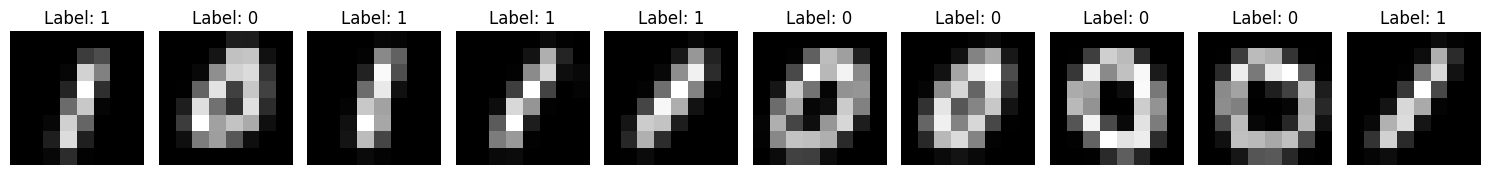

In [6]:

import matplotlib.pyplot as plt

def load_and_preprocess_mnist():
    # Build and prepare the MNIST dataset using tensorflow_datasets.
    ds_builder = tfds.builder("mnist")
    ds_builder.download_and_prepare()
    
    # Load the training split as supervised (image, label) pairs.
    ds = ds_builder.as_dataset(split="train", as_supervised=True)
    
    # Filter the dataset to include only digits 0 and 1.
    ds = ds.filter(lambda image, label: tf.logical_or(tf.equal(label, 0), tf.equal(label, 1)))
    
    images_list = []
    labels_list = []
    
    # Iterate over the dataset. Each image is originally 28x28x1.
    for image, label in tfds.as_numpy(ds):
        # Normalize image to [0, 1].
        image = image.astype(np.float32) / 255.0
        
        # Convert to a JAX array.
        image_jax = jnp.array(image)
        
        # Downsample the image to 8x8. Preserve the channel dimension.
        resized = jax.image.resize(image_jax, shape=(8, 8, image_jax.shape[-1]), method='linear')
        
        images_list.append(resized)
        labels_list.append(label)
    
    # Stack the images and labels into arrays.
    images_array = jnp.stack(images_list)
    labels_array = jnp.array(labels_list)
    
    return images_array, labels_array

# Load and preprocess the MNIST data.
images, labels = load_and_preprocess_mnist()

# Plot a few examples
num_examples = 10  # number of examples to display
fig, axes = plt.subplots(1, num_examples, figsize=(15, 2))

for i in range(num_examples):
    # Remove channel dimension if it exists (i.e., converting 8x8x1 to 8x8)
    img = images[i]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    
    axes[i].imshow(np.array(img), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Label: {labels[i]}")

plt.tight_layout()
plt.show()
